
# Bias & MAPE for Final Department Models

Loads the saved final models per department/target, scores them on the time-series **test split**, and reports bias (mean error) and MAPE. Metrics use the same feature construction as the modeling suites (forward-fill then zero-fill).


In [7]:

import numpy as np
import pandas as pd
from pathlib import Path
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import Ridge, ElasticNet  # needed for unpickling stacks
from sklearn.ensemble import StackingRegressor
from sklearn.pipeline import Pipeline

from catboost import CatBoostRegressor
try:
    from lightgbm import LGBMRegressor
except ImportError:
    LGBMRegressor = None
try:
    from xgboost import XGBRegressor
except ImportError:
    XGBRegressor = None


In [8]:

BASE_DIR = Path('.')
SPLITS_DIR = BASE_DIR / 'data' / 'processed' / 'timeseries_splits'
MODELS_DIR = BASE_DIR / 'models'

train = pd.read_csv(SPLITS_DIR / 'train_timeseries.csv', parse_dates=['dt'], low_memory=False)
test = pd.read_csv(SPLITS_DIR / 'test_timeseries.csv', parse_dates=['dt'], low_memory=False)

# Feature sets consistent with modeling notebooks
feature_columns_cases = [c for c in train.select_dtypes(include=['number']).columns if c != 'cases']
feature_columns_trucks = [c for c in train.select_dtypes(include=['number']).columns if c != 'trucks' and not c.startswith('cases')]

print('Loaded splits:', train.shape, test.shape)
print('Case features:', len(feature_columns_cases), '| Truck features:', len(feature_columns_trucks))


Loaded splits: (237000, 81) (10000, 81)
Case features: 69 | Truck features: 62


In [9]:

def safe_mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = y_true != 0
    if not mask.any():
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]))

def build_feature_matrix(df, feature_cols, target_col):
    X = df.reindex(columns=feature_cols).copy()
    # Forward-fill then zero-fill, matching modeling suites
    X = X.fillna(method='ffill').fillna(0)
    y = df[target_col]
    return X, y

def load_final_model(dept, target):
    fname = 'final_case_model.pkl' if target == 'cases' else 'final_truck_model.pkl'
    path = MODELS_DIR / f'dept{dept}' / fname
    if not path.exists():
        return None
    return joblib.load(path)


In [10]:

results = []

for dept_dir in sorted(MODELS_DIR.glob('dept*')):
    if not dept_dir.is_dir():
        continue
    dept = int(dept_dir.name.replace('dept', ''))
    dept_test = test[test['dept_id'] == dept].sort_values('dt').copy()
    if dept_test.empty:
        continue

    for target, feature_cols in [('cases', feature_columns_cases), ('trucks', feature_columns_trucks)]:
        model = load_final_model(dept, target)
        if model is None:
            continue

        X, y = build_feature_matrix(dept_test, feature_cols, target)
        valid_mask = y.notna()
        X_valid = X.loc[valid_mask]
        y_valid = y.loc[valid_mask]
        if y_valid.empty:
            continue

        preds = pd.Series(model.predict(X_valid), index=y_valid.index)
        err = preds - y_valid

        results.append({
            'dept': dept,
            'target': target,
            'rows': len(y_valid),
            'MAE': mean_absolute_error(y_valid, preds),
            'RMSE': mean_squared_error(y_valid, preds, squared=False),
            'MAPE': safe_mape(y_valid, preds),
            'bias': err.mean(),
        })

metrics_df = pd.DataFrame(results)
metrics_df = metrics_df.sort_values(['dept','target']).reset_index(drop=True)
metrics_df


/var/folders/hm/4ll25pyj60g_145pzvzm_jbh0000gn/T/ipykernel_56914/2430119114.py:12: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X = X.fillna(method='ffill').fillna(0)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/var/folders/hm/4ll25pyj60g_145pzvzm_jbh0000gn/T/ipykernel_56914/2430119114.py:12: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X = X.fillna(method='ffill').fillna(0)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the func

,dept,target,rows,MAE,RMSE,MAPE,bias
0,6,cases,2000,3.700258,5.567929,0.067771,-0.313602
1,6,trucks,2000,0.089883,0.202865,0.036460,-0.013272
2,9,cases,2000,3.790491,5.949846,0.064888,-0.490231
3,9,trucks,2000,0.090920,0.205606,0.036830,-0.013646
4,41,cases,2000,2.559341,4.068667,0.049192,-0.443040
5,41,trucks,2000,0.102657,0.224104,0.041772,-0.013024
6,67,cases,2000,3.775319,5.194052,0.067970,-0.242857
7,67,trucks,2000,0.099650,0.218277,0.040564,-0.012553
8,90,cases,2000,3.053728,4.398783,0.052442,-0.378118
9,90,trucks,2000,0.091411,0.204854,0.037159,-0.012061



    ## Residual and calibration checks
    Quick visuals to spot underfitting/overfitting on the test split for a chosen department/target.
    

In [11]:

# Pick a dept/target to visualize
dept_to_plot = 41
target_to_plot = 'cases'  # 'cases' or 'trucks'

sns.set_style('whitegrid')


/var/folders/hm/4ll25pyj60g_145pzvzm_jbh0000gn/T/ipykernel_56914/2430119114.py:12: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X = X.fillna(method='ffill').fillna(0)
/var/folders/hm/4ll25pyj60g_145pzvzm_jbh0000gn/T/ipykernel_56914/2016276428.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dec = viz.groupby('decile').agg(MAE=('resid', lambda s: np.abs(s).mean()), bias=('resid', 'mean')).reset_index()


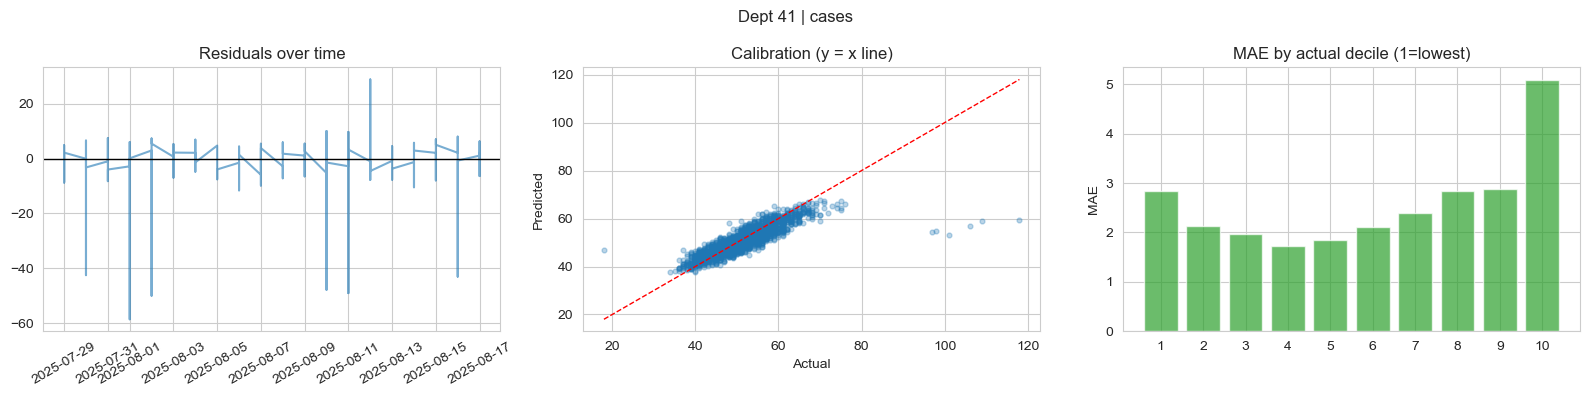

In [12]:

feature_cols = feature_columns_cases if target_to_plot == 'cases' else feature_columns_trucks
dept_df = test[test['dept_id'] == dept_to_plot].sort_values('dt').copy()
model = load_final_model(dept_to_plot, target_to_plot)

if dept_df.empty:
    print(f'No test rows for dept {dept_to_plot}')
elif model is None:
    print(f'Missing model for dept {dept_to_plot} {target_to_plot}')
else:
    X, y = build_feature_matrix(dept_df, feature_cols, target_to_plot)
    mask = y.notna()
    Xv, yv = X.loc[mask], y.loc[mask]
    preds = pd.Series(model.predict(Xv), index=yv.index)

    viz = dept_df.loc[mask, ['dt']].copy()
    viz['actual'] = yv.values
    viz['pred'] = preds.values
    viz['resid'] = viz['pred'] - viz['actual']

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # Residuals over time
    axes[0].plot(viz['dt'], viz['resid'], color='tab:blue', alpha=0.6, label='resid')
    axes[0].axhline(0, color='black', lw=1)
    axes[0].set_title('Residuals over time')
    axes[0].tick_params(axis='x', rotation=30)

    # Pred vs actual calibration
    axes[1].scatter(viz['actual'], viz['pred'], alpha=0.3, s=12)
    lims = [min(viz['actual'].min(), viz['pred'].min()), max(viz['actual'].max(), viz['pred'].max())]
    axes[1].plot(lims, lims, 'r--', lw=1)
    axes[1].set_xlabel('Actual')
    axes[1].set_ylabel('Predicted')
    axes[1].set_title('Calibration (y = x line)')

    # Error by actual decile
    viz['decile'] = pd.qcut(viz['actual'], 10, duplicates='drop')
    dec = viz.groupby('decile').agg(MAE=('resid', lambda s: np.abs(s).mean()), bias=('resid', 'mean')).reset_index()
    axes[2].bar(range(len(dec)), dec['MAE'], color='tab:green', alpha=0.7)
    axes[2].set_xticks(range(len(dec)))
    axes[2].set_xticklabels([f'{i+1}' for i in range(len(dec))], rotation=0)
    axes[2].set_title('MAE by actual decile (1=lowest)')
    axes[2].set_ylabel('MAE')

    fig.suptitle(f'Dept {dept_to_plot} | {target_to_plot}')
    plt.tight_layout()
    plt.show()


In [13]:

    if metrics_df.empty:
        print('No metrics computed; check that final models and test split exist.')
    else:
        print('Bias/MAE/MAPE on test split:')
        display(metrics_df)

        pivot = metrics_df.pivot(index='dept', columns='target', values='MAPE')
        print(' MAPE pivot (lower is better):')
        display(pivot)


Bias/MAE/MAPE on test split:


,dept,target,rows,MAE,RMSE,MAPE,bias
0,6,cases,2000,3.700258,5.567929,0.067771,-0.313602
1,6,trucks,2000,0.089883,0.202865,0.036460,-0.013272
2,9,cases,2000,3.790491,5.949846,0.064888,-0.490231
3,9,trucks,2000,0.090920,0.205606,0.036830,-0.013646
4,41,cases,2000,2.559341,4.068667,0.049192,-0.443040
5,41,trucks,2000,0.102657,0.224104,0.041772,-0.013024
6,67,cases,2000,3.775319,5.194052,0.067970,-0.242857
7,67,trucks,2000,0.099650,0.218277,0.040564,-0.012553
8,90,cases,2000,3.053728,4.398783,0.052442,-0.378118
9,90,trucks,2000,0.091411,0.204854,0.037159,-0.012061


 MAPE pivot (lower is better):


target,cases,trucks
dept,,
6,0.067771,0.036460
9,0.064888,0.036830
41,0.049192,0.041772
67,0.067970,0.040564
90,0.052442,0.037159
